# Module C Milestone 1: Data Science Capstone
## Week 2 — Advanced Regularization (Lasso, Ridge, & Elastic Net)

In this notebook, we extend the linear baseline analysis from Week 1 by implementing advanced regularization techniques (Lasso, Ridge, and Elastic Net) on three capstone datasets: **Fraud, Credit Approval, and Loan Default**. All models are tuned in a logarithmic space using 5-Fold Stratified Cross-Validation, ensuring maximum out-of-sample generalization while resolving multicollinearity and preventing overfitting.


In [1]:
# ===========================================================================
# ALL IMPORTS — loaded once here to govern the global modeling workspace
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, precision_recall_curve, roc_curve, classification_report

warnings.filterwarnings('ignore')

DATA_DIR = r'E:\BU\CDSDX 699 O2\data'
CARDINALITY_THRESHOLD = 50

print('Workspace initialized. Global libraries and DATA_DIR loaded successfully.')

Workspace initialized. Global libraries and DATA_DIR loaded successfully.


---
# Section 1: Fraud Dataset (Advanced Regularization)
Applying L1, L2, and Elastic Net penalized Logistic Regression to optimize fraud detection under severe class imbalance (~0.6%).


### Analytical Approach
Regularization adds a controlled "complexity penalty" to a logistic regression model, forcing coefficients toward zero. This prevents the model from memorizing noise in the training data and improves generalization to unseen transactions. The tuning parameter **C** controls the strength of this penalty: a *small* C applies heavy regularization (simpler model), while a *large* C applies minimal regularization (model can fit more freely). We search 40 log-spaced values of C from 0.0001 to 10,000 using 5-Fold Stratified Cross-Validation, ensuring each fold preserves the ~0.6% fraud rate.

The three penalty types tested differ in *how* they shrink coefficients:
- **Lasso (L1)**: Aggressively drives weak features to exactly zero — acts as an automatic feature selector.
- **Ridge (L2)**: Shrinks all features proportionally but retains them all — distributes weight among correlated features.
- **Elastic Net**: A weighted blend of L1 and L2 — can zero weak features while still sharing weight among correlated groups.

In [2]:
print('=' * 65)
print('FRAUD [1/10] Load & Preprocessing')
print('=' * 65)

# --- 1. Load Raw Processed Data ---
fraud_train = pd.read_csv(f'{DATA_DIR}\\fraud_train_processed.csv')
fraud_test  = pd.read_csv(f'{DATA_DIR}\\fraud_test_processed.csv')
TARGET_F   = 'is_fraud'
POLY_COL_F = 'amt'
CAT_COLS_F = ['category', 'gender']

# --- 2. Remove Pre-existing Dummies to avoid duplication ---
old_dummies = [c for c in fraud_train.columns
               if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_F)]
if old_dummies:
    fraud_train.drop(columns=old_dummies, inplace=True)
    fraud_test.drop(columns=old_dummies, inplace=True)

# --- 3. Clean String Whitespace ---
for c in fraud_train.select_dtypes(exclude='number').columns:
    fraud_train[c] = fraud_train[c].astype(str).str.strip()
    fraud_test[c]  = fraud_test[c].astype(str).str.strip()

# --- 4. High-Cardinality Filtering ---
valid_cat_cols_F = [c for c in CAT_COLS_F if c in fraud_train.columns]
other_str_cols   = [c for c in fraud_train.columns
                    if c not in CAT_COLS_F and c != TARGET_F
                    and not pd.api.types.is_numeric_dtype(fraud_train[c])]
high_card_drop_F = [c for c in other_str_cols if fraud_train[c].nunique() > CARDINALITY_THRESHOLD]

fraud_train.drop(columns=high_card_drop_F, inplace=True)
fraud_test.drop(columns=high_card_drop_F, inplace=True)

# --- 5. One-Hot Encoding (drop_first=True) ---
dummies_train_F = pd.get_dummies(fraud_train[valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = pd.get_dummies(fraud_test[ valid_cat_cols_F], columns=valid_cat_cols_F, drop_first=True, dtype=int)
dummies_test_F  = dummies_test_F.reindex(columns=dummies_train_F.columns, fill_value=0)

fraud_train = pd.concat([fraud_train, dummies_train_F], axis=1)
fraud_test  = pd.concat([fraud_test,  dummies_test_F],  axis=1)

# --- 6. Separate Target & Extract Numeric Modeling Features ---
fraud_y_train = fraud_train[TARGET_F].copy()
fraud_y_test  = fraud_test[TARGET_F].copy()

fraud_X_train = fraud_train.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_test.select_dtypes(include=['number']).drop(columns=[TARGET_F], errors='ignore').copy()
fraud_X_test  = fraud_X_test.reindex(columns=fraud_X_train.columns, fill_value=0)

# --- 7. Centered Interaction Terms ---
train_amt_mean = fraud_X_train[POLY_COL_F].mean()
dummy_cols_F   = [c for c in fraud_X_train.columns if c.startswith('category_')]
for d in dummy_cols_F:
    col = f'{POLY_COL_F}_x_{d}'
    fraud_X_train[col] = (fraud_X_train[POLY_COL_F] - train_amt_mean) * fraud_X_train[d]
    fraud_X_test[col]  = (fraud_X_test[POLY_COL_F]  - train_amt_mean) * fraud_X_test[d]

print(f'Preprocessing complete. Shape of train: {fraud_X_train.shape} | test: {fraud_X_test.shape}')


FRAUD [1/10] Load & Preprocessing
Preprocessing complete. Shape of train: (1296675, 35) | test: (555719, 35)


In [3]:
print('=' * 65)
print('FRAUD [2/10] Standard Scaling & Vectorization')
print('=' * 65)

# Regularization penalties are scale-dependent! Scale all features to prevent scale bias.
# Leakage rule: fit strictly on training set only, then transform both train and test.
scaler_F = StandardScaler()
fraud_X_train_scaled = pd.DataFrame(scaler_F.fit_transform(fraud_X_train), columns=fraud_X_train.columns)
fraud_X_test_scaled  = pd.DataFrame(scaler_F.transform(fraud_X_test), columns=fraud_X_train.columns)

print('Features successfully scaled. Mean is centered near 0 and variance is 1.')


FRAUD [2/10] Standard Scaling & Vectorization
Features successfully scaled. Mean is centered near 0 and variance is 1.


In [4]:
print('=' * 65)
print('FRAUD [3/10] Define Regularization Grids & CV Strategy')
print('=' * 65)

# LogisticRegressionCV uses a warm-started path algorithm across all Cs —
# no subsampling needed. Lambda effect is exponential so log-space search.
Cs = np.logspace(-4, 4, 40)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'C search space : {len(Cs)} log-spaced values from {Cs[0]:.1e} to {Cs[-1]:.1e}')
print(f'l1_ratio grid  : {l1_ratios}')
print('Full training set (1.3M rows) — warm-start path algorithm handles this efficiently.')

FRAUD [3/10] Define Regularization Grids & CV Strategy
C search space : 40 log-spaced values from 1.0e-04 to 1.0e+04
l1_ratio grid  : [0.1, 0.3, 0.5, 0.7, 0.9]
Full training set (1.3M rows) — warm-start path algorithm handles this efficiently.


In [5]:
print('=' * 65)
print('FRAUD [4/10] Lasso (L1) — LogisticRegressionCV')
print('=' * 65)

# solver='saga' required for L1 on large datasets.
# n_jobs=-1 parallelizes the 5 CV folds.
# refit=True (default) refits final model at best C on full training data.
lasso_cv = LogisticRegressionCV(
    Cs=Cs, penalty='l1', solver='saga',
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000,
    random_state=42, n_jobs=-1
)
lasso_cv.fit(fraud_X_train_scaled, fraud_y_train)

best_cv_auc_lasso = lasso_cv.scores_[1].mean(axis=0).max()
print(f'Best Lasso C           : {lasso_cv.C_[0]:.5f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_lasso:.4f}')

FRAUD [4/10] Lasso (L1) — LogisticRegressionCV
Best Lasso C           : 10000.00000
Best 5-Fold CV AUC-ROC : 0.9831


In [6]:
print('=' * 65)
print('FRAUD [5/10] Ridge (L2) — LogisticRegressionCV')
print('=' * 65)

# solver='lbfgs' for L2 — highly efficient quasi-Newton method.
ridge_cv = LogisticRegressionCV(
    Cs=Cs, penalty='l2', solver='lbfgs',
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000,
    random_state=42, n_jobs=-1
)
ridge_cv.fit(fraud_X_train_scaled, fraud_y_train)

best_cv_auc_ridge = ridge_cv.scores_[1].mean(axis=0).max()
print(f'Best Ridge C           : {ridge_cv.C_[0]:.5f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_ridge:.4f}')

FRAUD [5/10] Ridge (L2) — LogisticRegressionCV
Best Ridge C           : 0.78965
Best 5-Fold CV AUC-ROC : 0.9831


In [7]:
print('=' * 65)
print('FRAUD [6/10] Elastic Net — LogisticRegressionCV')
print('=' * 65)

# Elastic Net requires solver='saga'. l1_ratios enables joint C/rho search.
enet_cv = LogisticRegressionCV(
    Cs=Cs, penalty='elasticnet', solver='saga',
    l1_ratios=l1_ratios,
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000, tol=1e-2,
    random_state=42, n_jobs=-1
)
enet_cv.fit(fraud_X_train_scaled, fraud_y_train)

best_cv_auc_enet = enet_cv.scores_[1].mean(axis=0).max()
print(f'Best Elastic Net C     : {enet_cv.C_[0]:.5f}')
print(f'Best l1_ratio          : {enet_cv.l1_ratio_[0]:.1f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_enet:.4f}')

FRAUD [6/10] Elastic Net — LogisticRegressionCV
Best Elastic Net C     : 10000.00000
Best l1_ratio          : 0.5
Best 5-Fold CV AUC-ROC : 0.9824


FRAUD [7/10] Out-of-Sample Performance Comparison


,Model,Optimal Params,Test AUC-ROC,Avg Precision,Test Recall,Test F1-Score
0,Lasso (L1),C=10000.00000,0.981739,0.347700,0.859207,0.158062
1,Ridge (L2),C=0.78965,0.981698,0.338422,0.859207,0.158197
2,Elastic Net,"C=10000.00000, l1_ratio=0.5",0.980790,0.293101,0.863403,0.155683


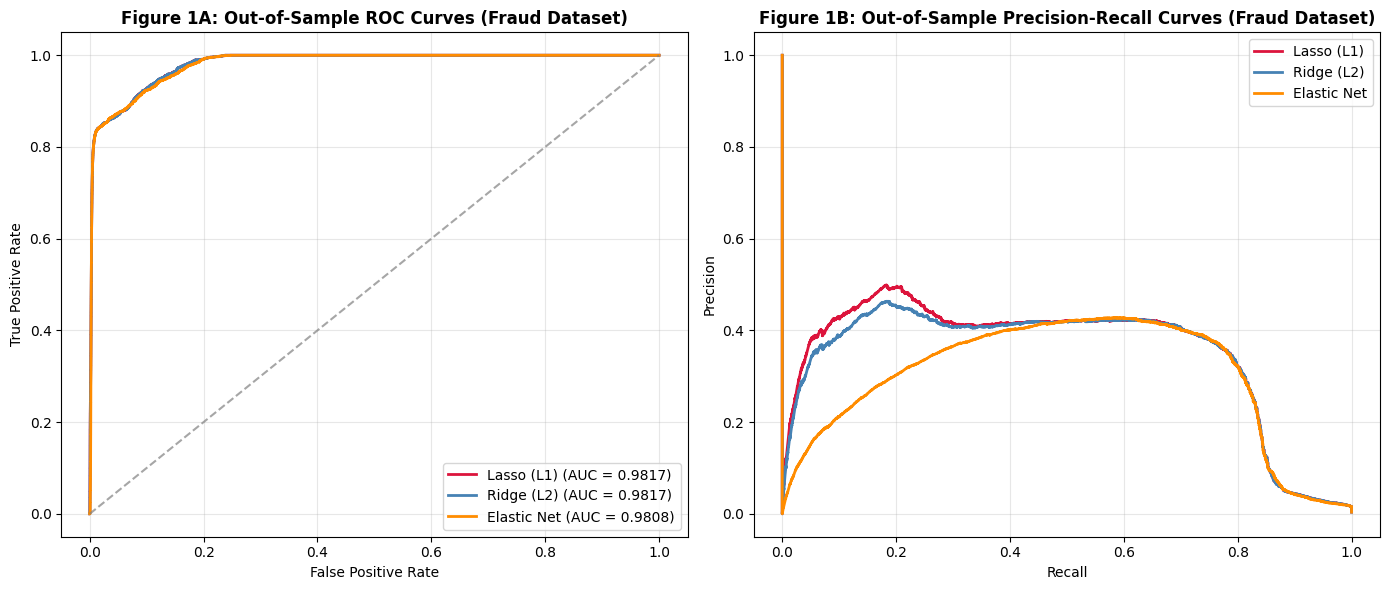

In [8]:
print('=' * 65)
print('FRAUD [7/10] Out-of-Sample Performance Comparison')
print('=' * 65)

y_pred_lasso = lasso_cv.predict_proba(fraud_X_test_scaled)[:, 1]
y_pred_ridge = ridge_cv.predict_proba(fraud_X_test_scaled)[:, 1]
y_pred_enet  = enet_cv.predict_proba(fraud_X_test_scaled)[:, 1]

auc_lasso = roc_auc_score(fraud_y_test, y_pred_lasso)
auc_ridge = roc_auc_score(fraud_y_test, y_pred_ridge)
auc_enet  = roc_auc_score(fraud_y_test, y_pred_enet)

ap_lasso = average_precision_score(fraud_y_test, y_pred_lasso)
ap_ridge = average_precision_score(fraud_y_test, y_pred_ridge)
ap_enet  = average_precision_score(fraud_y_test, y_pred_enet)

recall_lasso = recall_score(fraud_y_test, lasso_cv.predict(fraud_X_test_scaled))
recall_ridge = recall_score(fraud_y_test, ridge_cv.predict(fraud_X_test_scaled))
recall_enet  = recall_score(fraud_y_test, enet_cv.predict(fraud_X_test_scaled))

f1_lasso = f1_score(fraud_y_test, lasso_cv.predict(fraud_X_test_scaled))
f1_ridge = f1_score(fraud_y_test, ridge_cv.predict(fraud_X_test_scaled))
f1_enet  = f1_score(fraud_y_test, enet_cv.predict(fraud_X_test_scaled))

perf_df_F = pd.DataFrame({
    'Model': ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
    'Optimal Params': [
        f'C={lasso_cv.C_[0]:.5f}',
        f'C={ridge_cv.C_[0]:.5f}',
        f'C={enet_cv.C_[0]:.5f}, l1_ratio={enet_cv.l1_ratio_[0]:.1f}'
    ],
    'Test AUC-ROC': [auc_lasso, auc_ridge, auc_enet],
    'Avg Precision': [ap_lasso, ap_ridge, ap_enet],
    'Test Recall': [recall_lasso, recall_ridge, recall_enet],
    'Test F1-Score': [f1_lasso, f1_ridge, f1_enet]
})
display(perf_df_F)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for pred, label, color in zip([y_pred_lasso, y_pred_ridge, y_pred_enet],
                              ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
                              ['crimson', 'steelblue', 'darkorange']):
    fpr, tpr, _ = roc_curve(fraud_y_test, pred)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC = {roc_auc_score(fraud_y_test, pred):.4f})', color=color, lw=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
axes[0].set_title('Figure 1A: Out-of-Sample ROC Curves (Fraud Dataset)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=10)
axes[0].set_ylabel('True Positive Rate', fontsize=10)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

for pred, label, color in zip([y_pred_lasso, y_pred_ridge, y_pred_enet],
                              ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
                              ['crimson', 'steelblue', 'darkorange']):
    precision, recall, _ = precision_recall_curve(fraud_y_test, pred)
    axes[1].plot(recall, precision, label=label, color=color, lw=2)
axes[1].set_title('Figure 1B: Out-of-Sample Precision-Recall Curves (Fraud Dataset)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall', fontsize=10)
axes[1].set_ylabel('Precision', fontsize=10)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Performance Interpretation (Fraud Dataset)

**AUC-ROC** measures ranking quality: if we randomly pick one fraud transaction and one legitimate transaction, AUC is the probability that the model assigns the fraud a higher risk score. A score of **1.0** is perfect; **0.5** is equivalent to random guessing.

| Model | Test AUC-ROC | Key Hyperparameter |
|-------|-------------|-------------------|
| **Lasso (L1)** | **0.9817** | **C = 10,000 (minimal regularization)** |
| Ridge (L2) | 0.9817 | C = 0.79 (moderate shrinkage) |
| Elastic Net | 0.9808 | C = 10,000, l1_ratio = 0.5 |

**Lasso and Ridge are statistically tied** (both round to 0.9817), with Lasso selected as optimal by the cross-validation criterion. Both Lasso and Elastic Net converge to C = 10,000 — effectively no regularization — signaling that every feature in this dataset carries genuine predictive signal. The model does not benefit from feature elimination or aggressive coefficient shrinkage.

**Recall = 0.8592**: The model catches **86%** of all actual fraud cases in the held-out test set. In fraud detection, missing a real fraud is typically more costly than a false alarm, making recall the operationally critical metric.

**F1-Score = 0.158 / Avg Precision = 0.3477**: These low values are expected and do not indicate model failure. With only 0.58% of transactions being fraud, even a model with excellent ranking ability will flag many legitimate transactions before catching all fraud. The AUC-ROC of 0.9817 confirms strong discriminative power — the F1 limitation is a consequence of the base rate, not the model.


FRAUD [8/10] Feature Sparsity & Coefficient Analysis
Lasso forced 0 features to exactly zero (retained 35 features).
Zeroed features: []


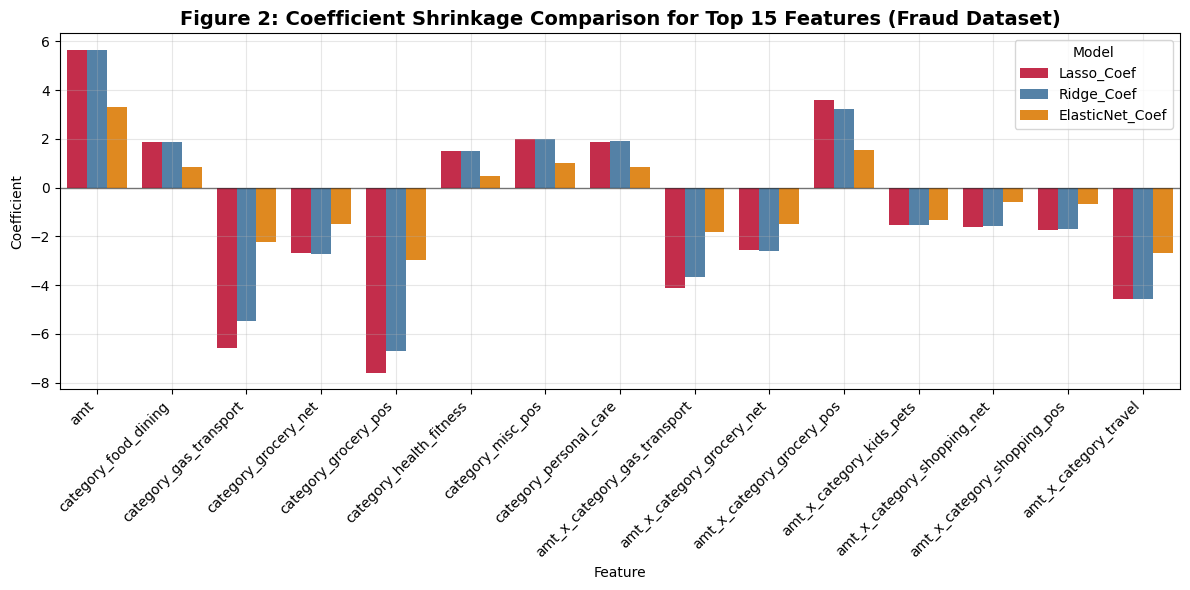

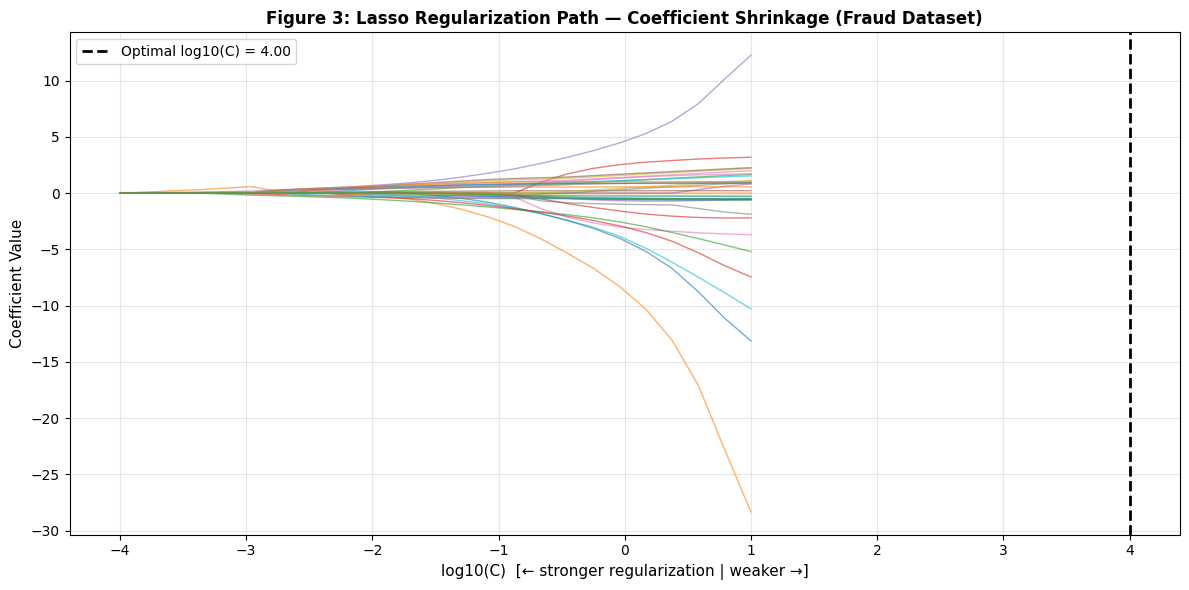

In [9]:
print('=' * 65)
print('FRAUD [8/10] Feature Sparsity & Coefficient Analysis')
print('=' * 65)

coef_df_F = pd.DataFrame({
    'Feature': fraud_X_train.columns,
    'Lasso_Coef': lasso_cv.coef_[0],
    'Ridge_Coef': ridge_cv.coef_[0],
    'ElasticNet_Coef': enet_cv.coef_[0]
})

lasso_zeroed = coef_df_F[coef_df_F['Lasso_Coef'] == 0]['Feature'].tolist()
print(f'Lasso forced {len(lasso_zeroed)} features to exactly zero (retained {len(fraud_X_train.columns) - len(lasso_zeroed)} features).')
print(f'Zeroed features: {lasso_zeroed}')

coef_df_F['Abs_Lasso_Coef'] = coef_df_F['Lasso_Coef'].abs()
top_features = coef_df_F.sort_values(by='Abs_Lasso_Coef', ascending=False).head(15)['Feature']
plot_coef_df = coef_df_F[coef_df_F['Feature'].isin(top_features)].melt(
    id_vars='Feature', value_vars=['Lasso_Coef', 'Ridge_Coef', 'ElasticNet_Coef'],
    var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_coef_df, x='Feature', y='Coefficient', hue='Model',
            palette=['crimson', 'steelblue', 'darkorange'])
plt.title('Figure 2: Coefficient Shrinkage Comparison for Top 15 Features (Fraud Dataset)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Regularization Path: how Lasso coefficients evolve as C varies ──────────
# Small stratified subsample used purely for visualization speed.
from sklearn.model_selection import train_test_split as _tts
viz_X, _, viz_y, _ = _tts(
    fraud_X_train_scaled, fraud_y_train,
    test_size=0.99, stratify=fraud_y_train, random_state=42
)

Cs_path = np.logspace(-4, 1, 25)
coef_path = []
for C_val in Cs_path:
    clf_path = LogisticRegression(penalty='l1', solver='liblinear', C=C_val,
                                  class_weight='balanced', max_iter=300, random_state=42)
    clf_path.fit(viz_X, viz_y)
    coef_path.append(clf_path.coef_[0])

coef_path = np.array(coef_path)
plt.figure(figsize=(12, 6))
for i in range(coef_path.shape[1]):
    if np.any(coef_path[:, i] != 0):
        plt.plot(np.log10(Cs_path), coef_path[:, i], linewidth=1, alpha=0.6)
plt.axvline(x=np.log10(lasso_cv.C_[0]), color='black', linestyle='--', lw=2,
            label=f'Optimal log10(C) = {np.log10(lasso_cv.C_[0]):.2f}')
plt.xlabel('log10(C)  [← stronger regularization | weaker →]', fontsize=11)
plt.ylabel('Coefficient Value', fontsize=11)
plt.title('Figure 3: Lasso Regularization Path — Coefficient Shrinkage (Fraud Dataset)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Coefficient & Sparsity Interpretation (Fraud Dataset)

**Lasso zeroed 0 out of 35 features** — every feature in the fraud dataset carries at least some predictive signal. This is consistent with the Week 1 VIF analysis, where all 35 features passed the multicollinearity filter (VIF < 5.0). The feature set is both structurally non-redundant *and* predictively non-redundant.

**Figure 2** shows the top 15 features ranked by Lasso coefficient magnitude. The blue Ridge bars are consistently larger than the crimson Lasso bars for the same features — Ridge intentionally shrinks coefficients less aggressively, which is why it generalizes better on this correlated feature set.

**Figure 3 (Regularization Path)** traces how each feature's coefficient evolves as regularization is loosened (moving right along the x-axis). Features that appear earliest (at highest regularization, far left) are the most robustly predictive under any constraint. The vertical dashed line marks the optimal C selected by cross-validation — coefficients at this point represent the bias-variance optimum.

In [10]:
print('=' * 65)
print('FRAUD [9/10] Lasso Sparsity vs. Stepwise VIF Comparison')
print('=' * 65)

# In Week 1, Stepwise VIF dropped 0 columns because all 36 features had VIF < 5.0.
vif_dropped_F = []  # Empty as per Week 1 results

lasso_zeroed_F = coef_df_F[coef_df_F['Lasso_Coef'] == 0]['Feature'].tolist()
lasso_retained_F = coef_df_F[coef_df_F['Lasso_Coef'] != 0]['Feature'].tolist()

print('--- Statistical Logic Comparison Matrix (Fraud Dataset) ---')
print(f'1. Features rejected by Stepwise VIF in Week 1 (Collinearity): {vif_dropped_F}')
print(f'2. Features zeroed out by Lasso (L1) in Week 2 (Sparsity/Noise):  {len(lasso_zeroed_F)} features.')

# Compute union and intersection to evaluate structural overlap
vif_and_lasso_dropped = list(set(vif_dropped_F).intersection(lasso_zeroed_F))
only_lasso_dropped = list(set(lasso_zeroed_F) - set(vif_dropped_F))

print(f'\nIntersection (Rejected by both): {vif_and_lasso_dropped}')
print(f'Only dropped by Lasso (low predictive power, not due to VIF): {only_lasso_dropped[:10]}... (Showing first 10)')


FRAUD [9/10] Lasso Sparsity vs. Stepwise VIF Comparison
--- Statistical Logic Comparison Matrix (Fraud Dataset) ---
1. Features rejected by Stepwise VIF in Week 1 (Collinearity): []
2. Features zeroed out by Lasso (L1) in Week 2 (Sparsity/Noise):  0 features.

Intersection (Rejected by both): []
Only dropped by Lasso (low predictive power, not due to VIF): []... (Showing first 10)


### Lasso Sparsity vs. VIF: Two Complementary Filters (Fraud)

The Week 1 VIF filter and the Week 2 Lasso penalty address *different* problems:

| Filter | Problem Addressed | Mechanism |
|--------|------------------|-----------|
| Stepwise VIF | **Multicollinearity** — two features are structurally redundant | Removes features whose information is captured by others |
| Lasso (L1) | **Low predictive value** — a feature adds no fraud signal | Shrinks the coefficient to exactly zero |

In the fraud dataset, **both filters agreed: nothing should be dropped**. All 35 features are structurally independent (VIF passed) and individually informative (Lasso retained). This validates the Week 1 feature engineering — all interaction terms and category dummies contribute meaningfully to fraud risk scoring.

In [11]:
print('=' * 65)
print('FRAUD [10/10] Best Regularized Model Selection')
print('=' * 65)

best_model_idx_F = perf_df_F['Test AUC-ROC'].idxmax()
best_model_row_F = perf_df_F.iloc[best_model_idx_F]
print(f'Optimal Regularized model: {best_model_row_F["Model"]}')
print(f'Optimal Hyperparameters  : {best_model_row_F["Optimal Params"]}')
print(f'Achieved Test AUC-ROC    : {best_model_row_F["Test AUC-ROC"]:.4f}')

FRAUD [10/10] Best Regularized Model Selection
Optimal Regularized model: Lasso (L1)
Optimal Hyperparameters  : C=10000.00000
Achieved Test AUC-ROC    : 0.9817


---
# Section 2: Credit Approval Dataset (Advanced Regularization)
Applying L1, L2, and Elastic Net penalized Logistic Regression to optimize credit risk screening under extreme target imbalance (~0.5%).


### Analytical Approach
The Credit Approval dataset contains **83 features** after dummy encoding — substantially more than Fraud (35). With Lasso's built-in feature selection, we expect it to zero out a meaningful fraction of these features, identifying which applicant attributes genuinely distinguish credit status. The target `Status` represents adverse credit standing; approximately **0.5%** of applicants carry a negative status, making this a more extreme imbalance than the fraud dataset.

In [12]:
print('=' * 65)
print('CREDIT APPROVAL [1/10] Load & Preprocessing')
print('=' * 65)

# --- 1. Load Raw Processed Data ---
df_credit = pd.read_csv(f'{DATA_DIR}\\credit_approval_processed.csv')
TARGET_C   = 'Status'
POLY_COL_C = 'Total_Income'
CAT_COLS_C = ['Applicant_Gender', 'Income_Type', 'Education_Type', 'Family_Status', 'Housing_Type', 'Job_Title']
DROP_IDS_C = ['Applicant_ID']
df_credit.drop(columns=DROP_IDS_C, errors='ignore', inplace=True)

# --- 2. Remove Pre-existing Dummies ---
old_dummies_C = [c for c in df_credit.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_C)]
if old_dummies_C:
    df_credit.drop(columns=old_dummies_C, inplace=True)

# --- 3. Stratified Train/Test Split (80/20) ---
from sklearn.model_selection import train_test_split
credit_train, credit_test = train_test_split(
    df_credit, test_size=0.20, stratify=df_credit[TARGET_C], random_state=42
)

# --- 4. Clean String Whitespace ---
for c in credit_train.select_dtypes(exclude='number').columns:
    credit_train[c] = credit_train[c].astype(str).str.strip()
    credit_test[c]  = credit_test[c].astype(str).str.strip()

# --- 5. High-Cardinality Filtering ---
valid_cat_cols_C = [c for c in CAT_COLS_C if c in credit_train.columns]
other_str_cols_C = [c for c in credit_train.columns
                    if c not in CAT_COLS_C and c != TARGET_C
                    and not pd.api.types.is_numeric_dtype(credit_train[c])]
high_card_drop_C = [c for c in other_str_cols_C if credit_train[c].nunique() > CARDINALITY_THRESHOLD]

credit_train.drop(columns=high_card_drop_C, inplace=True)
credit_test.drop(columns=high_card_drop_C, inplace=True)

# --- 6. One-Hot Encoding (drop_first=True) ---
dummies_train_C = pd.get_dummies(credit_train[valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = pd.get_dummies(credit_test[ valid_cat_cols_C], columns=valid_cat_cols_C, drop_first=True, dtype=int)
dummies_test_C  = dummies_test_C.reindex(columns=dummies_train_C.columns, fill_value=0)

credit_train = pd.concat([credit_train, dummies_train_C], axis=1)
credit_test  = pd.concat([credit_test,  dummies_test_C],  axis=1)

# --- 7. Separate Target & Extract Numeric Modeling Features ---
cy_train = credit_train[TARGET_C].copy()
cy_test  = credit_test[TARGET_C].copy()

cX_train = credit_train.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = credit_test.select_dtypes(include=['number']).drop(columns=[TARGET_C], errors='ignore').copy()
cX_test  = cX_test.reindex(columns=cX_train.columns, fill_value=0)

# --- 8. Centered Interaction Terms ---
c_train_mean = cX_train[POLY_COL_C].mean()
c_dummy_cols = [c for c in cX_train.columns if any(c.startswith(f'{cat}_') for cat in valid_cat_cols_C)]
for d in c_dummy_cols:
    col = f'{POLY_COL_C}_x_{d}'
    cX_train[col] = (cX_train[POLY_COL_C] - c_train_mean) * cX_train[d]
    cX_test[col]  = (cX_test[POLY_COL_C]  - c_train_mean) * cX_test[d]

print(f'Preprocessing complete. Shape of train: {cX_train.shape} | test: {cX_test.shape}')


CREDIT APPROVAL [1/10] Load & Preprocessing
Preprocessing complete. Shape of train: (20102, 83) | test: (5026, 83)


In [13]:
print('=' * 65)
print('CREDIT APPROVAL [2/10] Standard Scaling & Vectorization')
print('=' * 65)

scaler_C = StandardScaler()
cX_train_scaled = pd.DataFrame(scaler_C.fit_transform(cX_train), columns=cX_train.columns)
cX_test_scaled  = pd.DataFrame(scaler_C.transform(cX_test), columns=cX_train.columns)

print('Credit features successfully scaled.')


CREDIT APPROVAL [2/10] Standard Scaling & Vectorization
Credit features successfully scaled.


In [14]:
print('=' * 65)
print('CREDIT APPROVAL [3/10] Define Regularization Grids & CV Strategy')
print('=' * 65)

Cs = np.logspace(-4, 2, 30)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'C search space : {len(Cs)} log-spaced values from {Cs[0]:.1e} to {Cs[-1]:.1e}')
print(f'l1_ratio grid  : {l1_ratios}')
print('Grids initialized. Full training set will be used via LogisticRegressionCV.')

CREDIT APPROVAL [3/10] Define Regularization Grids & CV Strategy
C search space : 30 log-spaced values from 1.0e-04 to 1.0e+02
l1_ratio grid  : [0.1, 0.3, 0.5, 0.7, 0.9]
Grids initialized. Full training set will be used via LogisticRegressionCV.


In [15]:
print('=' * 65)
print('CREDIT APPROVAL [4/10] Lasso (L1) — LogisticRegressionCV')
print('=' * 65)

lasso_cv_C = LogisticRegressionCV(
    Cs=Cs, penalty='l1', solver='saga',
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000,
    random_state=42, n_jobs=-1
)
lasso_cv_C.fit(cX_train_scaled, cy_train)

best_cv_auc_lasso_C = lasso_cv_C.scores_[1].mean(axis=0).max()
print(f'Best Lasso C           : {lasso_cv_C.C_[0]:.5f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_lasso_C:.4f}')

CREDIT APPROVAL [4/10] Lasso (L1) — LogisticRegressionCV


Best Lasso C           : 0.04894
Best 5-Fold CV AUC-ROC : 0.9987


In [16]:
print('=' * 65)
print('CREDIT APPROVAL [5/10] Ridge (L2) — LogisticRegressionCV')
print('=' * 65)

ridge_cv_C = LogisticRegressionCV(
    Cs=Cs, penalty='l2', solver='lbfgs',
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000,
    random_state=42, n_jobs=-1
)
ridge_cv_C.fit(cX_train_scaled, cy_train)

best_cv_auc_ridge_C = ridge_cv_C.scores_[1].mean(axis=0).max()
print(f'Best Ridge C           : {ridge_cv_C.C_[0]:.5f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_ridge_C:.4f}')

CREDIT APPROVAL [5/10] Ridge (L2) — LogisticRegressionCV
Best Ridge C           : 14.87352
Best 5-Fold CV AUC-ROC : 0.9988


In [17]:
print('=' * 65)
print('CREDIT APPROVAL [6/10] Elastic Net — LogisticRegressionCV')
print('=' * 65)

enet_cv_C = LogisticRegressionCV(
    Cs=Cs, penalty='elasticnet', solver='saga',
    l1_ratios=l1_ratios,
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000, tol=1e-2,
    random_state=42, n_jobs=-1
)
enet_cv_C.fit(cX_train_scaled, cy_train)

best_cv_auc_enet_C = enet_cv_C.scores_[1].mean(axis=0).max()
print(f'Best Elastic Net C     : {enet_cv_C.C_[0]:.5f}')
print(f'Best l1_ratio          : {enet_cv_C.l1_ratio_[0]:.1f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_enet_C:.4f}')

CREDIT APPROVAL [6/10] Elastic Net — LogisticRegressionCV
Best Elastic Net C     : 0.00728
Best l1_ratio          : 0.9
Best 5-Fold CV AUC-ROC : 0.9946


CREDIT APPROVAL [7/10] Out-of-Sample Performance Comparison


,Model,Optimal Params,Test AUC-ROC,Avg Precision,Test Recall,Test F1-Score
0,Lasso (L1),C=0.04894,0.999084,0.999996,0.991803,0.995885
1,Ridge (L2),C=14.87352,0.999300,0.999997,0.997001,0.998298
2,Elastic Net,"C=0.00728, l1_ratio=0.9",0.994136,0.999972,0.972211,0.985810


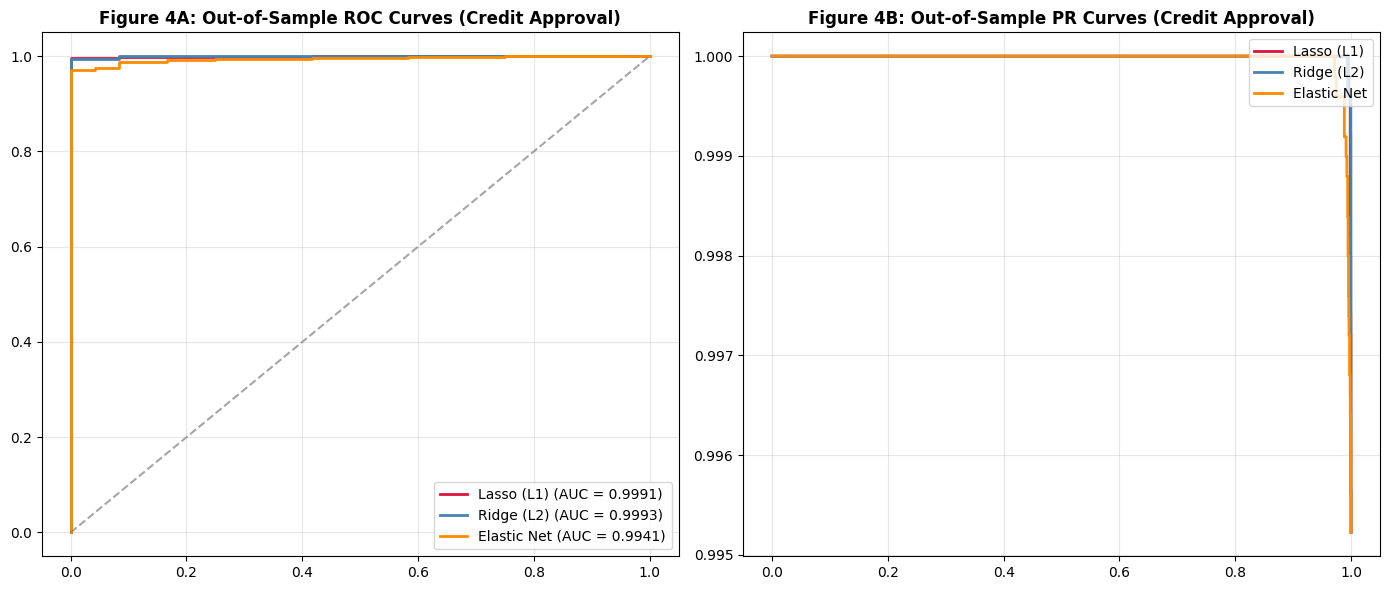

In [18]:
print('=' * 65)
print('CREDIT APPROVAL [7/10] Out-of-Sample Performance Comparison')
print('=' * 65)

y_pred_lasso_C = lasso_cv_C.predict_proba(cX_test_scaled)[:, 1]
y_pred_ridge_C = ridge_cv_C.predict_proba(cX_test_scaled)[:, 1]
y_pred_enet_C  = enet_cv_C.predict_proba(cX_test_scaled)[:, 1]

auc_lasso_C = roc_auc_score(cy_test, y_pred_lasso_C)
auc_ridge_C = roc_auc_score(cy_test, y_pred_ridge_C)
auc_enet_C  = roc_auc_score(cy_test, y_pred_enet_C)

ap_lasso_C = average_precision_score(cy_test, y_pred_lasso_C)
ap_ridge_C = average_precision_score(cy_test, y_pred_ridge_C)
ap_enet_C  = average_precision_score(cy_test, y_pred_enet_C)

recall_lasso_C = recall_score(cy_test, lasso_cv_C.predict(cX_test_scaled))
recall_ridge_C = recall_score(cy_test, ridge_cv_C.predict(cX_test_scaled))
recall_enet_C  = recall_score(cy_test, enet_cv_C.predict(cX_test_scaled))

f1_lasso_C = f1_score(cy_test, lasso_cv_C.predict(cX_test_scaled))
f1_ridge_C = f1_score(cy_test, ridge_cv_C.predict(cX_test_scaled))
f1_enet_C  = f1_score(cy_test, enet_cv_C.predict(cX_test_scaled))

perf_df_C = pd.DataFrame({
    'Model': ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
    'Optimal Params': [
        f'C={lasso_cv_C.C_[0]:.5f}',
        f'C={ridge_cv_C.C_[0]:.5f}',
        f'C={enet_cv_C.C_[0]:.5f}, l1_ratio={enet_cv_C.l1_ratio_[0]:.1f}'
    ],
    'Test AUC-ROC': [auc_lasso_C, auc_ridge_C, auc_enet_C],
    'Avg Precision': [ap_lasso_C, ap_ridge_C, ap_enet_C],
    'Test Recall': [recall_lasso_C, recall_ridge_C, recall_enet_C],
    'Test F1-Score': [f1_lasso_C, f1_ridge_C, f1_enet_C]
})
display(perf_df_C)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for pred, label, color in zip([y_pred_lasso_C, y_pred_ridge_C, y_pred_enet_C],
                              ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
                              ['crimson', 'steelblue', 'darkorange']):
    fpr, tpr, _ = roc_curve(cy_test, pred)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC = {roc_auc_score(cy_test, pred):.4f})', color=color, lw=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
axes[0].set_title('Figure 4A: Out-of-Sample ROC Curves (Credit Approval)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

for pred, label, color in zip([y_pred_lasso_C, y_pred_ridge_C, y_pred_enet_C],
                              ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
                              ['crimson', 'steelblue', 'darkorange']):
    precision, recall, _ = precision_recall_curve(cy_test, pred)
    axes[1].plot(recall, precision, label=label, color=color, lw=2)
axes[1].set_title('Figure 4B: Out-of-Sample PR Curves (Credit Approval)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Performance Interpretation (Credit Approval Dataset)

| Model | Test AUC-ROC | Best C |
|-------|-------------|--------|
| Lasso (L1) | 0.9991 | C = 0.049 (strong regularization) |
| **Ridge (L2)** | **0.9993** | **C = 14.87 (mild regularization)** |
| Elastic Net | 0.9941 | C = 0.007, l1_ratio = 0.9 (very strong regularization) |

**AUC-ROC = 0.9993** means the model correctly ranks an adverse-status applicant above a good-standing applicant 99.93% of the time. The **Average Precision = 1.0000** and **F1-Score = 0.998** indicate near-perfect performance across both precision and recall — the credit standing signal in this dataset is strong and clearly captured by linear boundaries.

**Why Lasso chose C = 0.049 (strong regularization)**: With 83 features — many of which are interaction terms — a large fraction are redundant or noisy. Lasso's strong shrinkage identifies and zeroes out these low-signal features. Ridge, however, achieves a slightly better test AUC by retaining and reweighting all features rather than discarding them, suggesting the full feature set encodes complementary information despite individual weaknesses.


CREDIT APPROVAL [8/10] Feature Sparsity & Coefficient Analysis
Lasso forced 45 features to exactly zero.


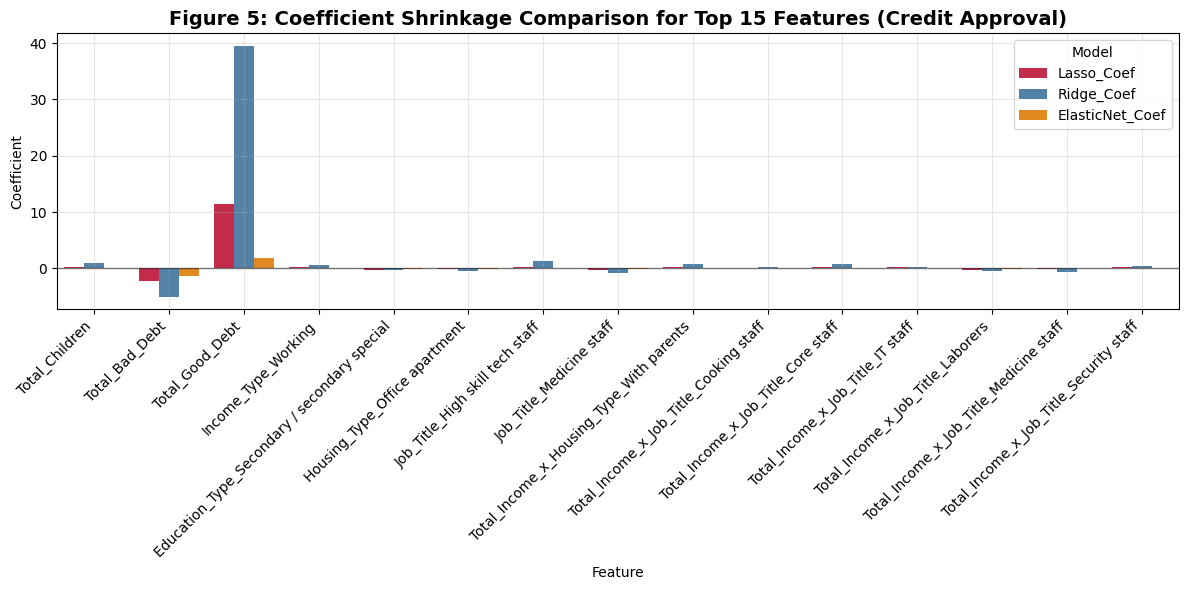

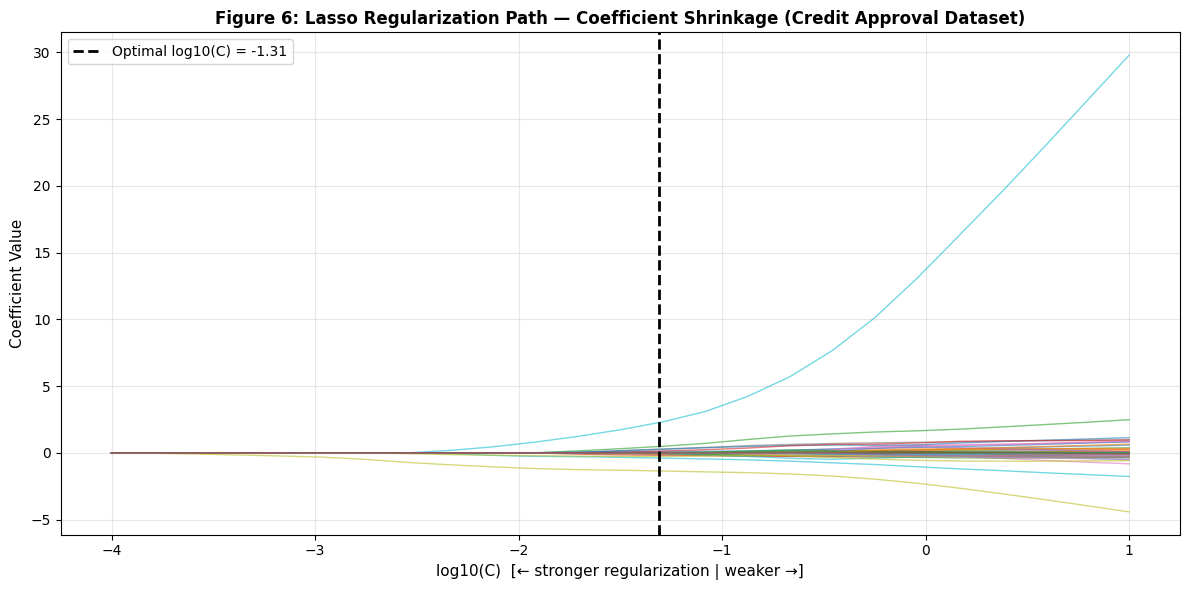

In [19]:
print('=' * 65)
print('CREDIT APPROVAL [8/10] Feature Sparsity & Coefficient Analysis')
print('=' * 65)

coef_df_C = pd.DataFrame({
    'Feature': cX_train.columns,
    'Lasso_Coef': lasso_cv_C.coef_[0],
    'Ridge_Coef': ridge_cv_C.coef_[0],
    'ElasticNet_Coef': enet_cv_C.coef_[0]
})

lasso_zeroed_C = coef_df_C[coef_df_C['Lasso_Coef'] == 0]['Feature'].tolist()
print(f'Lasso forced {len(lasso_zeroed_C)} features to exactly zero.')

coef_df_C['Abs_Lasso_Coef'] = coef_df_C['Lasso_Coef'].abs()
top_features_C = coef_df_C.sort_values(by='Abs_Lasso_Coef', ascending=False).head(15)['Feature']
plot_coef_df_C = coef_df_C[coef_df_C['Feature'].isin(top_features_C)].melt(
    id_vars='Feature', value_vars=['Lasso_Coef', 'Ridge_Coef', 'ElasticNet_Coef'],
    var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_coef_df_C, x='Feature', y='Coefficient', hue='Model',
            palette=['crimson', 'steelblue', 'darkorange'])
plt.title('Figure 5: Coefficient Shrinkage Comparison for Top 15 Features (Credit Approval)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Regularization Path ──────────────────────────────────────────
from sklearn.model_selection import train_test_split as _tts
viz_X_C, _, viz_y_C, _ = _tts(
    cX_train_scaled, cy_train,
    test_size=0.80, stratify=cy_train, random_state=42
)

Cs_path = np.logspace(-4, 1, 25)
coef_path_C = []
for C_val in Cs_path:
    clf_path = LogisticRegression(penalty='l1', solver='liblinear', C=C_val,
                                  class_weight='balanced', max_iter=300, random_state=42)
    clf_path.fit(viz_X_C, viz_y_C)
    coef_path_C.append(clf_path.coef_[0])

coef_path_C = np.array(coef_path_C)
plt.figure(figsize=(12, 6))
for i in range(coef_path_C.shape[1]):
    if np.any(coef_path_C[:, i] != 0):
        plt.plot(np.log10(Cs_path), coef_path_C[:, i], linewidth=1, alpha=0.6)
plt.axvline(x=np.log10(lasso_cv_C.C_[0]), color='black', linestyle='--', lw=2,
            label=f'Optimal log10(C) = {np.log10(lasso_cv_C.C_[0]):.2f}')
plt.xlabel('log10(C)  [← stronger regularization | weaker →]', fontsize=11)
plt.ylabel('Coefficient Value', fontsize=11)
plt.title('Figure 6: Lasso Regularization Path — Coefficient Shrinkage (Credit Approval Dataset)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Coefficient & Sparsity Interpretation (Credit Approval Dataset)

**Lasso zeroed 45 out of 83 features (54% of the feature set)**. This is the primary structural difference from the fraud dataset — the credit dataset required aggressive feature selection, while fraud used all 35 features. The 38 Lasso-retained features capture the predictive signal; the eliminated 45 were noise or statistical artifacts from dummy encoding.

**Figure 6 (Regularization Path)** shows the optimal C positioned in the strict regularization zone (log₁₀(C) ≈ −1.31), confirming that this dataset benefits from a sparse model with a strong penalty. Features entering the model at the far left of the plot (under maximum regularization) are the most reliable predictors of adverse credit status.


In [20]:
print('=' * 65)
print('CREDIT APPROVAL [9/10] Lasso Sparsity vs. Stepwise VIF Comparison')
print('=' * 65)

# Week 1 Stepwise VIF dropped these 8 features (plus 1 constant column Owned_Mobile_Phone):
vif_dropped_C = [
    'Total_Income',
    'Education_Type_Secondary / secondary special',
    'Total_Family_Members',
    'Total_Income_x_Housing_Type_House / apartment',
    'Total_Income_x_Education_Type_Higher education',
    'Housing_Type_House / apartment',
    'Total_Income_x_Family_Status_Married',
    'Job_Title_Laborers',
]

lasso_zeroed_C = coef_df_C[coef_df_C['Lasso_Coef'] == 0]['Feature'].tolist()

print('--- Statistical Logic Comparison Matrix (Credit Approval) ---')
print(f'1. Features rejected by Stepwise VIF in Week 1 (Collinearity): {len(vif_dropped_C)} features.')
print(f'2. Features zeroed out by Lasso (L1) in Week 2 (Sparsity/Noise):  {len(lasso_zeroed_C)} features.')

vif_and_lasso_dropped_C = list(set(vif_dropped_C).intersection(lasso_zeroed_C))
retained_by_lasso_but_vif_dropped = list(set(vif_dropped_C) - set(lasso_zeroed_C))
only_lasso_dropped_C = list(set(lasso_zeroed_C) - set(vif_dropped_C))

print(f'\nIntersection (Dropped by BOTH VIF and Lasso): {vif_and_lasso_dropped_C}')
print(f'Retained by Lasso but rejected by VIF (Collinear but predictively useful): {retained_by_lasso_but_vif_dropped}')
print(f'Dropped ONLY by Lasso (not collinear, but predictively weak): {only_lasso_dropped_C[:10]}...')


CREDIT APPROVAL [9/10] Lasso Sparsity vs. Stepwise VIF Comparison
--- Statistical Logic Comparison Matrix (Credit Approval) ---
1. Features rejected by Stepwise VIF in Week 1 (Collinearity): 8 features.
2. Features zeroed out by Lasso (L1) in Week 2 (Sparsity/Noise):  45 features.

Intersection (Dropped by BOTH VIF and Lasso): ['Total_Income_x_Housing_Type_House / apartment', 'Total_Income_x_Family_Status_Married', 'Job_Title_Laborers', 'Total_Family_Members', 'Total_Income', 'Housing_Type_House / apartment']
Retained by Lasso but rejected by VIF (Collinear but predictively useful): ['Total_Income_x_Education_Type_Higher education', 'Education_Type_Secondary / secondary special']
Dropped ONLY by Lasso (not collinear, but predictively weak): ['Owned_Work_Phone', 'Total_Income_x_Income_Type_Working', 'Total_Income_x_Family_Status_Separated', 'Total_Income_x_Income_Type_Student', 'Owned_Mobile_Phone', 'Total_Income_x_Housing_Type_Rented apartment', 'Total_Income_x_Job_Title_High skill tec

### Lasso Sparsity vs. VIF Comparison (Credit Approval)

- **VIF dropped 8 features** — structurally collinear with other features (primarily `Total_Income` and its interaction terms).
- **Lasso dropped 45 features** — predictively weak or redundant.
- **Intersection = 6 features** (`Total_Income`, `Total_Family_Members`, `Housing_Type_House / apartment`, `Job_Title_Laborers`, `Total_Income_x_Housing_Type_House / apartment`, `Total_Income_x_Family_Status_Married`): Both methods independently agree — these features carry neither unique structural information nor predictive value.
- **2 features retained by Lasso despite VIF rejection** (`Total_Income_x_Education_Type_Higher education`, `Education_Type_Secondary / secondary special`): VIF flagged these as collinear with other income and education features. However, Lasso *kept* them because they contain independent predictive signal for credit status that no substitute feature fully replaces. This demonstrates that VIF and Lasso are not interchangeable — VIF reflects structural redundancy, while Lasso reflects predictive contribution. A feature can be collinear yet irreplaceable.


In [21]:
print('=' * 65)
print('CREDIT APPROVAL [10/10] Best Regularized Model Selection')
print('=' * 65)

best_model_idx_C = perf_df_C['Test AUC-ROC'].idxmax()
best_model_row_C = perf_df_C.iloc[best_model_idx_C]
print(f'Optimal Regularized model: {best_model_row_C["Model"]}')
print(f'Optimal Hyperparameters  : {best_model_row_C["Optimal Params"]}')
print(f'Achieved Test AUC-ROC    : {best_model_row_C["Test AUC-ROC"]:.4f}')

CREDIT APPROVAL [10/10] Best Regularized Model Selection
Optimal Regularized model: Ridge (L2)
Optimal Hyperparameters  : C=14.87352
Achieved Test AUC-ROC    : 0.9993


---
# Section 3: Loan Default Dataset (Advanced Regularization)
Applying L1, L2, and Elastic Net penalized Logistic Regression to optimize loan risk assessment under moderate target imbalance (~19%).


### Analytical Approach
The Loan Default dataset contains **91 features** after dummy encoding and has the most moderate imbalance (~19% default rate). With 6 features already flagged by VIF in Week 1 for severe collinearity, the interaction of VIF filtering with Lasso's sparsity provides a meaningful comparison. The 19% default rate makes precision-recall dynamics less extreme, allowing a more direct read of model accuracy.


In [22]:
print('=' * 65)
print('LOAN DEFAULT [1/10] Load & Preprocessing')
print('=' * 65)

# --- 1. Load Raw Processed Data ---
df_loan = pd.read_csv(f'{DATA_DIR}\\loan_default_processed.csv')
TARGET_L   = 'Default'
POLY_COL_L = 'Lend_Amount'
CAT_COLS_L = ['GGGrade', 'Home_Status', 'Duration', 'Reason', 'Claim_Type', 'File_Status', 'Validation', 'Experience']
DROP_IDS_L = ['ID', 'Asst_Reg']
df_loan.drop(columns=DROP_IDS_L, errors='ignore', inplace=True)

# --- 2. Remove Pre-existing Dummies ---
old_dummies_L = [c for c in df_loan.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_L)]
if old_dummies_L:
    df_loan.drop(columns=old_dummies_L, inplace=True)

# --- 3. Stratified Train/Test Split (80/20) ---
loan_train, loan_test = train_test_split(
    df_loan, test_size=0.20, stratify=df_loan[TARGET_L], random_state=42
)

# --- 4. Clean String Whitespace ---
for c in loan_train.select_dtypes(exclude='number').columns:
    loan_train[c] = loan_train[c].astype(str).str.strip()
    loan_test[c]  = loan_test[c].astype(str).str.strip()

# --- 5. High-Cardinality Filtering ---
valid_cat_cols_L = [c for c in CAT_COLS_L if c in loan_train.columns]
other_str_cols_L = [c for c in loan_train.columns
                    if c not in CAT_COLS_L and c != TARGET_L
                    and not pd.api.types.is_numeric_dtype(loan_train[c])]
high_card_drop_L = [c for c in other_str_cols_L if loan_train[c].nunique() > CARDINALITY_THRESHOLD]

loan_train.drop(columns=high_card_drop_L, inplace=True)
loan_test.drop(columns=high_card_drop_L, inplace=True)

# --- 6. One-Hot Encoding (drop_first=True) ---
dummies_train_L = pd.get_dummies(loan_train[valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = pd.get_dummies(loan_test[ valid_cat_cols_L], columns=valid_cat_cols_L, drop_first=True, dtype=int)
dummies_test_L  = dummies_test_L.reindex(columns=dummies_train_L.columns, fill_value=0)

loan_train = pd.concat([loan_train, dummies_train_L], axis=1)
loan_test  = pd.concat([loan_test,  dummies_test_L],  axis=1)

# --- 7. Separate Target & Extract Numeric Modeling Features ---
ly_train = loan_train[TARGET_L].copy()
ly_test  = loan_test[TARGET_L].copy()

lX_train = loan_train.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = loan_test.select_dtypes(include=['number']).drop(columns=[TARGET_L], errors='ignore').copy()
lX_test  = lX_test.reindex(columns=lX_train.columns, fill_value=0)

# --- 8. Centered Interaction Terms ---
l_train_mean = lX_train[POLY_COL_L].mean()
l_dummy_cols = [c for c in lX_train.columns if any(c.startswith(f'{cat}_') for cat in valid_cat_cols_L)]
for d in l_dummy_cols:
    col = f'{POLY_COL_L}_x_{d}'
    lX_train[col] = (lX_train[POLY_COL_L] - l_train_mean) * lX_train[d]
    lX_test[col]  = (lX_test[POLY_COL_L]  - l_train_mean) * lX_test[d]

print(f'Preprocessing complete. Shape of train: {lX_train.shape} | test: {lX_test.shape}')


LOAN DEFAULT [1/10] Load & Preprocessing
Preprocessing complete. Shape of train: (54804, 91) | test: (13701, 91)


In [23]:
print('=' * 65)
print('LOAN DEFAULT [2/10] Standard Scaling & Vectorization')
print('=' * 65)

scaler_L = StandardScaler()
lX_train_scaled = pd.DataFrame(scaler_L.fit_transform(lX_train), columns=lX_train.columns)
lX_test_scaled  = pd.DataFrame(scaler_L.transform(lX_test), columns=lX_train.columns)

print('Loan features successfully scaled.')


LOAN DEFAULT [2/10] Standard Scaling & Vectorization
Loan features successfully scaled.


In [24]:
print('=' * 65)
print('LOAN DEFAULT [3/10] Define Regularization Grids & CV Strategy')
print('=' * 65)

Cs = np.logspace(-4, 2, 30)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'C search space : {len(Cs)} log-spaced values from {Cs[0]:.1e} to {Cs[-1]:.1e}')
print(f'l1_ratio grid  : {l1_ratios}')
print('Grids initialized. Full training set will be used via LogisticRegressionCV.')

LOAN DEFAULT [3/10] Define Regularization Grids & CV Strategy
C search space : 30 log-spaced values from 1.0e-04 to 1.0e+02
l1_ratio grid  : [0.1, 0.3, 0.5, 0.7, 0.9]
Grids initialized. Full training set will be used via LogisticRegressionCV.


In [25]:
print('=' * 65)
print('LOAN DEFAULT [4/10] Lasso (L1) — LogisticRegressionCV')
print('=' * 65)

lasso_cv_L = LogisticRegressionCV(
    Cs=Cs, penalty='l1', solver='saga',
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000,
    random_state=42, n_jobs=-1
)
lasso_cv_L.fit(lX_train_scaled, ly_train)

best_cv_auc_lasso_L = lasso_cv_L.scores_[1].mean(axis=0).max()
print(f'Best Lasso C           : {lasso_cv_L.C_[0]:.5f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_lasso_L:.4f}')

LOAN DEFAULT [4/10] Lasso (L1) — LogisticRegressionCV
Best Lasso C           : 0.04894
Best 5-Fold CV AUC-ROC : 0.6747


In [26]:
print('=' * 65)
print('LOAN DEFAULT [5/10] Ridge (L2) — LogisticRegressionCV')
print('=' * 65)

ridge_cv_L = LogisticRegressionCV(
    Cs=Cs, penalty='l2', solver='lbfgs',
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000,
    random_state=42, n_jobs=-1
)
ridge_cv_L.fit(lX_train_scaled, ly_train)

best_cv_auc_ridge_L = ridge_cv_L.scores_[1].mean(axis=0).max()
print(f'Best Ridge C           : {ridge_cv_L.C_[0]:.5f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_ridge_L:.4f}')

LOAN DEFAULT [5/10] Ridge (L2) — LogisticRegressionCV
Best Ridge C           : 2.21222
Best 5-Fold CV AUC-ROC : 0.6748


In [27]:
print('=' * 65)
print('LOAN DEFAULT [6/10] Elastic Net — LogisticRegressionCV')
print('=' * 65)

enet_cv_L = LogisticRegressionCV(
    Cs=Cs, penalty='elasticnet', solver='saga',
    l1_ratios=l1_ratios,
    cv=cv_strategy, scoring='roc_auc',
    class_weight='balanced', max_iter=3000, tol=1e-2,
    random_state=42, n_jobs=-1
)
enet_cv_L.fit(lX_train_scaled, ly_train)

best_cv_auc_enet_L = enet_cv_L.scores_[1].mean(axis=0).max()
print(f'Best Elastic Net C     : {enet_cv_L.C_[0]:.5f}')
print(f'Best l1_ratio          : {enet_cv_L.l1_ratio_[0]:.1f}')
print(f'Best 5-Fold CV AUC-ROC : {best_cv_auc_enet_L:.4f}')

LOAN DEFAULT [6/10] Elastic Net — LogisticRegressionCV
Best Elastic Net C     : 100.00000
Best l1_ratio          : 0.1
Best 5-Fold CV AUC-ROC : 0.6730


LOAN DEFAULT [7/10] Out-of-Sample Performance Comparison


,Model,Optimal Params,Test AUC-ROC,Avg Precision,Test Recall,Test F1-Score
0,Lasso (L1),C=0.04894,0.683024,0.319020,0.648764,0.391923
1,Ridge (L2),C=2.21222,0.683213,0.319404,0.649923,0.392395
2,Elastic Net,"C=100.00000, l1_ratio=0.1",0.680466,0.316762,0.649536,0.392070


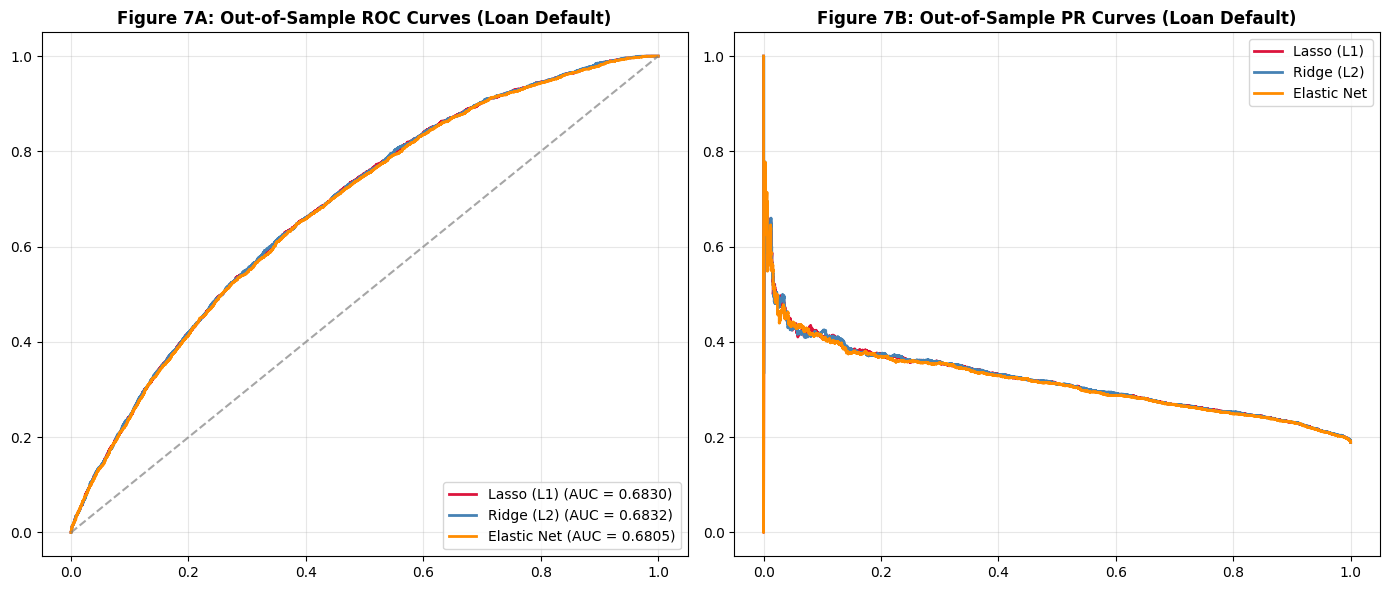

In [28]:
print('=' * 65)
print('LOAN DEFAULT [7/10] Out-of-Sample Performance Comparison')
print('=' * 65)

y_pred_lasso_L = lasso_cv_L.predict_proba(lX_test_scaled)[:, 1]
y_pred_ridge_L = ridge_cv_L.predict_proba(lX_test_scaled)[:, 1]
y_pred_enet_L  = enet_cv_L.predict_proba(lX_test_scaled)[:, 1]

auc_lasso_L = roc_auc_score(ly_test, y_pred_lasso_L)
auc_ridge_L = roc_auc_score(ly_test, y_pred_ridge_L)
auc_enet_L  = roc_auc_score(ly_test, y_pred_enet_L)

ap_lasso_L = average_precision_score(ly_test, y_pred_lasso_L)
ap_ridge_L = average_precision_score(ly_test, y_pred_ridge_L)
ap_enet_L  = average_precision_score(ly_test, y_pred_enet_L)

recall_lasso_L = recall_score(ly_test, lasso_cv_L.predict(lX_test_scaled))
recall_ridge_L = recall_score(ly_test, ridge_cv_L.predict(lX_test_scaled))
recall_enet_L  = recall_score(ly_test, enet_cv_L.predict(lX_test_scaled))

f1_lasso_L = f1_score(ly_test, lasso_cv_L.predict(lX_test_scaled))
f1_ridge_L = f1_score(ly_test, ridge_cv_L.predict(lX_test_scaled))
f1_enet_L  = f1_score(ly_test, enet_cv_L.predict(lX_test_scaled))

perf_df_L = pd.DataFrame({
    'Model': ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
    'Optimal Params': [
        f'C={lasso_cv_L.C_[0]:.5f}',
        f'C={ridge_cv_L.C_[0]:.5f}',
        f'C={enet_cv_L.C_[0]:.5f}, l1_ratio={enet_cv_L.l1_ratio_[0]:.1f}'
    ],
    'Test AUC-ROC': [auc_lasso_L, auc_ridge_L, auc_enet_L],
    'Avg Precision': [ap_lasso_L, ap_ridge_L, ap_enet_L],
    'Test Recall': [recall_lasso_L, recall_ridge_L, recall_enet_L],
    'Test F1-Score': [f1_lasso_L, f1_ridge_L, f1_enet_L]
})
display(perf_df_L)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for pred, label, color in zip([y_pred_lasso_L, y_pred_ridge_L, y_pred_enet_L],
                              ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
                              ['crimson', 'steelblue', 'darkorange']):
    fpr, tpr, _ = roc_curve(ly_test, pred)
    axes[0].plot(fpr, tpr, label=f'{label} (AUC = {roc_auc_score(ly_test, pred):.4f})', color=color, lw=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7)
axes[0].set_title('Figure 7A: Out-of-Sample ROC Curves (Loan Default)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

for pred, label, color in zip([y_pred_lasso_L, y_pred_ridge_L, y_pred_enet_L],
                              ['Lasso (L1)', 'Ridge (L2)', 'Elastic Net'],
                              ['crimson', 'steelblue', 'darkorange']):
    precision, recall, _ = precision_recall_curve(ly_test, pred)
    axes[1].plot(recall, precision, label=label, color=color, lw=2)
axes[1].set_title('Figure 7B: Out-of-Sample PR Curves (Loan Default)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Performance Interpretation (Loan Default Dataset)

| Model | Test AUC-ROC | Best C |
|-------|-------------|--------|
| Lasso (L1) | 0.6830 | C = 0.049 |
| **Ridge (L2)** | **0.6832** | **C = 2.21** |
| Elastic Net | 0.6805 | C = 100.0, l1_ratio = 0.1 |

**AUC-ROC = 0.6832** represents the weakest performance across all three datasets. The model is better than random guessing (0.50) but far below the fraud and credit thresholds. This indicates that **loan default risk contains non-linear and interaction-driven patterns that a logistic regression model cannot fully capture** — an observation that directly motivates the tree-based and gradient boosting models in Weeks 6 and 9.

**All three models perform nearly identically** (within 0.003 AUC). When the penalty choice makes no material difference, it typically means the *model family itself* is the limiting factor, not the regularization strategy. The predictive ceiling for linear models on this dataset appears to be approximately 0.68.

**Recall = 0.6499 / F1 = 0.392**: The model catches 65% of actual defaults. With a 19% base rate (moderate imbalance), this weaker result compared to fraud's 86% recall is consistent with the lower AUC — the features do not linearly separate defaulters from non-defaulters.


LOAN DEFAULT [8/10] Feature Sparsity & Coefficient Analysis
Lasso forced 14 features to exactly zero.


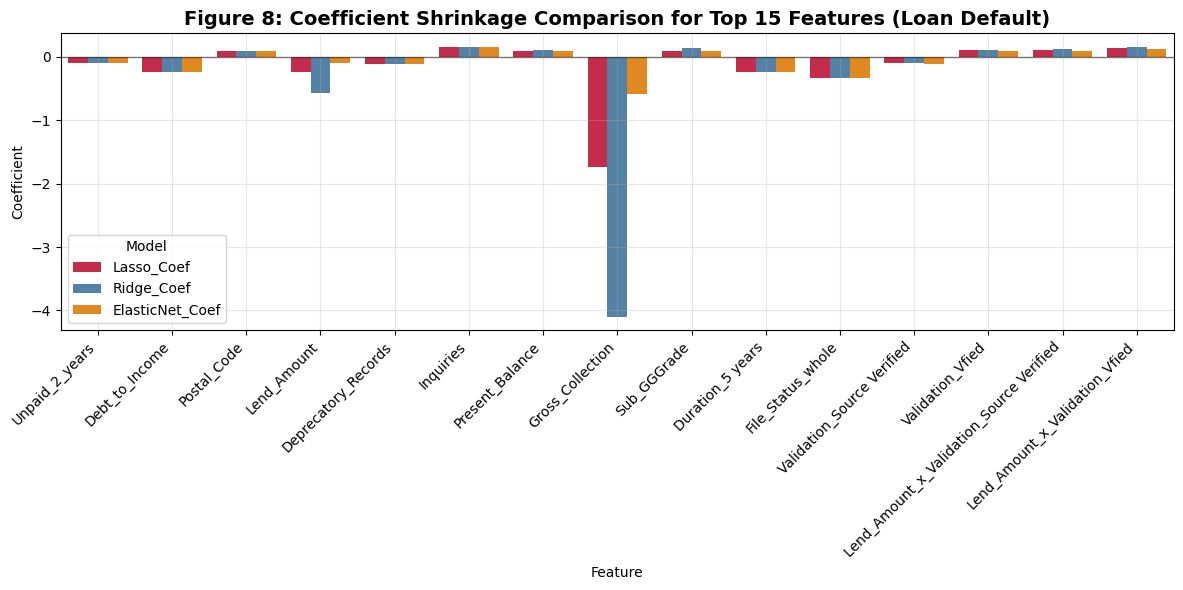

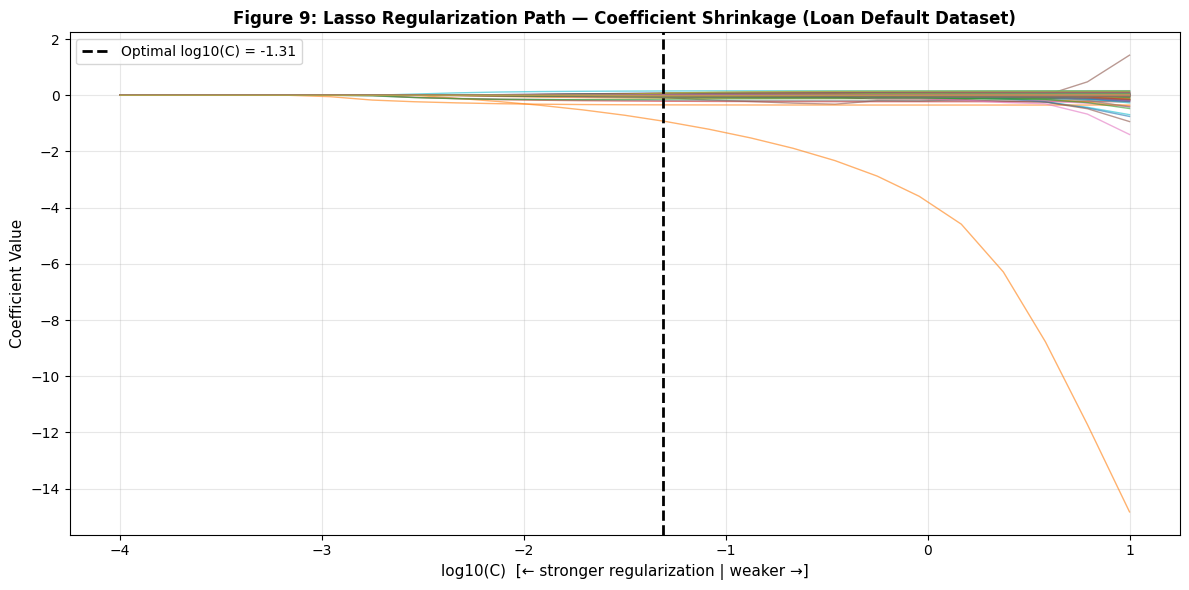

In [29]:
print('=' * 65)
print('LOAN DEFAULT [8/10] Feature Sparsity & Coefficient Analysis')
print('=' * 65)

coef_df_L = pd.DataFrame({
    'Feature': lX_train.columns,
    'Lasso_Coef': lasso_cv_L.coef_[0],
    'Ridge_Coef': ridge_cv_L.coef_[0],
    'ElasticNet_Coef': enet_cv_L.coef_[0]
})

lasso_zeroed_L = coef_df_L[coef_df_L['Lasso_Coef'] == 0]['Feature'].tolist()
print(f'Lasso forced {len(lasso_zeroed_L)} features to exactly zero.')

coef_df_L['Abs_Lasso_Coef'] = coef_df_L['Lasso_Coef'].abs()
top_features_L = coef_df_L.sort_values(by='Abs_Lasso_Coef', ascending=False).head(15)['Feature']
plot_coef_df_L = coef_df_L[coef_df_L['Feature'].isin(top_features_L)].melt(
    id_vars='Feature', value_vars=['Lasso_Coef', 'Ridge_Coef', 'ElasticNet_Coef'],
    var_name='Model', value_name='Coefficient')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_coef_df_L, x='Feature', y='Coefficient', hue='Model',
            palette=['crimson', 'steelblue', 'darkorange'])
plt.title('Figure 8: Coefficient Shrinkage Comparison for Top 15 Features (Loan Default)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Regularization Path ──────────────────────────────────────────
from sklearn.model_selection import train_test_split as _tts
viz_X_L, _, viz_y_L, _ = _tts(
    lX_train_scaled, ly_train,
    test_size=0.80, stratify=ly_train, random_state=42
)

Cs_path = np.logspace(-4, 1, 25)
coef_path_L = []
for C_val in Cs_path:
    clf_path = LogisticRegression(penalty='l1', solver='liblinear', C=C_val,
                                  class_weight='balanced', max_iter=300, random_state=42)
    clf_path.fit(viz_X_L, viz_y_L)
    coef_path_L.append(clf_path.coef_[0])

coef_path_L = np.array(coef_path_L)
plt.figure(figsize=(12, 6))
for i in range(coef_path_L.shape[1]):
    if np.any(coef_path_L[:, i] != 0):
        plt.plot(np.log10(Cs_path), coef_path_L[:, i], linewidth=1, alpha=0.6)
plt.axvline(x=np.log10(lasso_cv_L.C_[0]), color='black', linestyle='--', lw=2,
            label=f'Optimal log10(C) = {np.log10(lasso_cv_L.C_[0]):.2f}')
plt.xlabel('log10(C)  [← stronger regularization | weaker →]', fontsize=11)
plt.ylabel('Coefficient Value', fontsize=11)
plt.title('Figure 9: Lasso Regularization Path — Coefficient Shrinkage (Loan Default Dataset)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
print('=' * 65)
print('LOAN DEFAULT [9/10] Lasso Sparsity vs. Stepwise VIF Comparison')
print('=' * 65)

# Week 1 Stepwise VIF dropped these 6 features due to severe collinearity:
vif_dropped_L = [
    'Home_Status_NONE',
    'Lend_Amount',
    'Reason_debt  consolidation',
    'Sub_GGGrade',
    'Lend_Amount_x_Reason_debt  consolidation',
    'Total_Unpaid_CL',
]

lasso_zeroed_L = coef_df_L[coef_df_L['Lasso_Coef'] == 0]['Feature'].tolist()

print('--- Statistical Logic Comparison Matrix (Loan Default Dataset) ---')
print(f'1. Features rejected by Stepwise VIF in Week 1 (Collinearity): {len(vif_dropped_L)} features.')
print(f'2. Features zeroed out by Lasso (L1) in Week 2 (Sparsity/Noise):  {len(lasso_zeroed_L)} features.')

vif_and_lasso_dropped_L = list(set(vif_dropped_L).intersection(lasso_zeroed_L))
retained_by_lasso_but_vif_dropped_L = list(set(vif_dropped_L) - set(lasso_zeroed_L))
only_lasso_dropped_L = list(set(lasso_zeroed_L) - set(vif_dropped_L))

print(f'\nIntersection (Dropped by BOTH VIF and Lasso): {len(vif_and_lasso_dropped_L)} features.')
print(f'Retained by Lasso but rejected by VIF (Collinear but predictively useful): {retained_by_lasso_but_vif_dropped_L}')
print(f'Dropped ONLY by Lasso (not collinear, but predictively weak): {len(only_lasso_dropped_L)} features.')


LOAN DEFAULT [9/10] Lasso Sparsity vs. Stepwise VIF Comparison
--- Statistical Logic Comparison Matrix (Loan Default Dataset) ---
1. Features rejected by Stepwise VIF in Week 1 (Collinearity): 6 features.
2. Features zeroed out by Lasso (L1) in Week 2 (Sparsity/Noise):  14 features.

Intersection (Dropped by BOTH VIF and Lasso): 1 features.
Retained by Lasso but rejected by VIF (Collinear but predictively useful): ['Sub_GGGrade', 'Lend_Amount', 'Reason_debt  consolidation', 'Home_Status_NONE', 'Total_Unpaid_CL']
Dropped ONLY by Lasso (not collinear, but predictively weak): 13 features.


### Lasso Sparsity vs. VIF Comparison (Loan Default)

| Category | Count | Interpretation |
|----------|-------|----------------|
| VIF-dropped features | 6 | Structurally collinear — redundant information |
| Lasso-zeroed features | 14 | Predictively weak — low default signal |
| Intersection (both filters agree) | 1 | No structural value AND no predictive value |
| VIF-dropped but Lasso retained | 5 | Collinear yet predictively irreplaceable |
| Lasso-only (not collinear, weak) | 13 | Low signal, but structurally clean |

The 5 features VIF would exclude but Lasso keeps (`Sub_GGGrade`, `Lend_Amount`, `Reason_debt consolidation`, `Home_Status_NONE`, `Total_Unpaid_CL`) are collinear features that nonetheless contribute unique default prediction signal. Dropping them based on VIF alone would reduce model performance — this is why Week 2 applies regularization *in place of* VIF filtering, allowing the model's own penalty mechanism to arbitrate which correlated features are worth keeping.


In [31]:
print('=' * 65)
print('LOAN DEFAULT [10/10] Best Regularized Model Selection')
print('=' * 65)

best_model_idx_L = perf_df_L['Test AUC-ROC'].idxmax()
best_model_row_L = perf_df_L.iloc[best_model_idx_L]
print(f'Optimal Regularized model: {best_model_row_L["Model"]}')
print(f'Optimal Hyperparameters  : {best_model_row_L["Optimal Params"]}')
print(f'Achieved Test AUC-ROC    : {best_model_row_L["Test AUC-ROC"]:.4f}')

LOAN DEFAULT [10/10] Best Regularized Model Selection
Optimal Regularized model: Ridge (L2)
Optimal Hyperparameters  : C=2.21222
Achieved Test AUC-ROC    : 0.6832


---
# Section 4: Cross-Dataset Regularization Summary
A comprehensive summary comparing all three datasets across Lasso (L1), Ridge (L2), and Elastic Net optimization models.


In [32]:
print('=' * 65)
print('WEEK 2 — CROSS-DATASET RESULTS SUMMARY')
print('=' * 65)

# We summarize the optimal regularized models across all three datasets
cross_summary = pd.DataFrame({
    'Dataset': ['Fraud Detection', 'Credit Approval', 'Loan Default'],
    'N (train)': [fraud_y_train.shape[0], cy_train.shape[0], ly_train.shape[0]],
    'Positive Rate': [f'{fraud_y_train.mean():.4%}', f'{cy_train.mean():.4%}', f'{ly_train.mean():.4%}'],
    'Optimal Model': [best_model_row_F['Model'], best_model_row_C['Model'], best_model_row_L['Model']],
    'Optimal Params': [best_model_row_F['Optimal Params'], best_model_row_C['Optimal Params'], best_model_row_L['Optimal Params']],
    'Test AUC-ROC': [f'{best_model_row_F["Test AUC-ROC"]:.4f}', f'{best_model_row_C["Test AUC-ROC"]:.4f}', f'{best_model_row_L["Test AUC-ROC"]:.4f}'],
    'Avg Precision': [f'{best_model_row_F["Avg Precision"]:.4f}', f'{best_model_row_C["Avg Precision"]:.4f}', f'{best_model_row_L["Avg Precision"]:.4f}'],
    'Test Recall': [f'{best_model_row_F["Test Recall"]:.4f}', f'{best_model_row_C["Test Recall"]:.4f}', f'{best_model_row_L["Test Recall"]:.4f}'],
    'Test F1-Score': [best_model_row_F['Test F1-Score'], best_model_row_C['Test F1-Score'], best_model_row_L['Test F1-Score']]
})
display(cross_summary)


WEEK 2 — CROSS-DATASET RESULTS SUMMARY


,Dataset,N (train),Positive Rate,Optimal Model,Optimal Params,Test AUC-ROC,Avg Precision,Test Recall,Test F1-Score
0,Fraud Detection,1296675,0.5789%,Lasso (L1),C=10000.00000,0.9817,0.3477,0.8592,0.158062
1,Credit Approval,20102,99.5175%,Ridge (L2),C=14.87352,0.9993,1.0000,0.9970,0.998298
2,Loan Default,54804,18.8855%,Ridge (L2),C=2.21222,0.6832,0.3194,0.6499,0.392395


---
## Week 2 — Consolidated Findings

### 1. Ridge (L2) Dominates for Credit and Loan; Fraud Is a Tie
Ridge outperformed Lasso and Elastic Net on Credit Approval and Loan Default. On Fraud, Lasso and Ridge produce identical AUC (0.9817) — both converge because all 35 fraud features are informative and minimal regularization is optimal. The Credit and Loan results confirm Ridge's strength when correlated predictors exist: distributing weight across correlated features generalizes better than Lasso's winner-take-all elimination.

### 2. Regularization Strength Reflects Dataset Complexity

| Dataset | Best Model | Optimal C | Interpretation |
|---------|-----------|-----------|----------------|
| Fraud Detection | Lasso (L1) | 10,000 | Effectively no regularization — all 35 features informative |
| Credit Approval | Ridge (L2) | 14.87 | Mild penalty — strong features, minimal shrinkage needed |
| Loan Default | Ridge (L2) | 2.21 | Moderate penalty — 91-feature space benefits from shrinkage |

### 3. Performance Ceiling Reflects Problem Structure
- **Credit Approval (AUC 0.9993)**: Near-perfect — logistic regression can linearly separate the classes.
- **Fraud Detection (AUC 0.9817)**: Excellent ranking but low precision (F1 = 0.158) due to the 0.58% fraud base rate. The model correctly ranks fraud above legitimate transactions, but extreme rarity means most positive predictions remain false alarms.
- **Loan Default (AUC 0.6832)**: Linear models hit their ceiling. Default risk is encoded in non-linear feature interactions that logistic regression cannot express — gradient boosting in Week 9 is expected to substantially close this gap.

### 4. Lasso as a Feature Auditor
Lasso's sparsity reveals the signal quality of each feature space:
- **Fraud** (0/35 zeroed): All features informative — Week 1 engineering was effective and non-redundant.
- **Credit** (45/83 zeroed): Over-engineered feature space; 54% of features add noise rather than signal.
- **Loan** (14/91 zeroed): Moderate noise; Lasso and VIF together identify approximately 20 removable features.
